In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target

print(X.shape, y.shape)          # predict these before running
print(X.min(), X.max())          # pixel range
print(np.bincount(y))            # how many examples of each digit 0–9

(1797, 64) (1797,)
0.0 16.0
[178 182 177 183 181 182 181 179 174 180]


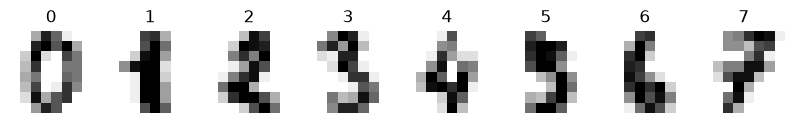

In [2]:
fig, axes = plt.subplots(1, 8, figsize=(10, 2))
for ax, img, label in zip(axes, X[:8], y[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray_r")   # 64 pixels back into 8×8
    ax.set_title(label)
    ax.axis("off")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
def compute_distances(A, B):
    A_squared = np.sum(A**2, axis=1, keepdims=True)
    B_squared = np.sum(B**2, axis=1)
    AB = A @ B.T
    D2 = np.maximum(A_squared + B_squared - 2 * AB, 0)  # clamp negatives to zero before doing root of d2
    return np.sqrt(D2)

In [10]:
def predict_1nn(X_train, y_train,X_test):
    D = compute_distances(X_test, X_train)
    nearest_neighbor_indices = np.argmin(D, axis=1)
    return y_train[nearest_neighbor_indices]


In [12]:
preds = predict_1nn(X_train, y_train, X_test)
accuracy = np.mean(preds == y_test)
print(f"1-NN accuracy: {accuracy:.4f}")


1-NN accuracy: 0.9861


In [13]:
predict_1nn(X_train, y_train, X_train[:20])  # predict the first 5 test examples

array([5, 0, 5, 7, 1, 2, 9, 9, 2, 0, 8, 8, 7, 9, 2, 5, 8, 9, 0, 7])

In [15]:
accuracy = np.mean(predict_1nn(X_train, y_train, X_train) == y_train)
print(f"1-NN training accuracy: {accuracy:.4f}")

1-NN training accuracy: 1.0000
